# BizIntel LangGraph — Visualization & Basic Testing

This notebook:
1. Builds the BizIntel LangGraph pipeline
2. Renders the graph as a **Mermaid** diagram
3. Invokes the graph with a sample query for basic smoke-testing

In [1]:
# ── 0. Setup: ensure the project root is on sys.path ────────────────────
import sys, pathlib

PROJECT_ROOT = pathlib.Path.cwd().parent  # notebooks/ -> BizIntel/
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

# Load .env so API keys are available
from dotenv import load_dotenv
load_dotenv(PROJECT_ROOT / ".env")

print(f"Project root : {PROJECT_ROOT}")
print(f"Source dir   : {SRC_DIR}")

Project root : c:\Users\ShubhankDubey\Shubhank_All\EPAM-2026\learning-projects\BizIntel
Source dir   : c:\Users\ShubhankDubey\Shubhank_All\EPAM-2026\learning-projects\BizIntel\src


In [4]:
%pip install rank-bm25 tavily-python --quiet

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## 1. Build the Graph

In [5]:
from bizintel.embeddings.embedder import StartupEmbedder
from bizintel.vectorstore.base import create_vector_store
from bizintel.rag.retriever import StartupRetriever
from bizintel.config.llm_client import get_llm_client
from bizintel.config.settings import (
    VECTOR_STORE_BACKEND, RERANK_ENABLED, HYBRID_SEARCH_ENABLED,
)
from bizintel.graph.builder import build_graph

# Load components
embedder = StartupEmbedder()
store    = create_vector_store(VECTOR_STORE_BACKEND)
print(f"Vector store loaded — {store.count:,} documents")

reranker = None
if RERANK_ENABLED:
    from bizintel.rag.reranker import StartupReranker
    reranker = StartupReranker()

bm25_index = None
if HYBRID_SEARCH_ENABLED:
    from bizintel.search.bm25_search import BM25Index
    doc_ids, texts, metadatas = store.get_all_documents()
    bm25_index = BM25Index(doc_ids, texts, metadatas)



retriever  = StartupRetriever(embedder, store, reranker=reranker, bm25_index=bm25_index)
llm_client = get_llm_client()

import os
from bizintel.config.settings import WEB_SEARCH_ENABLED
tavily_client = None
if WEB_SEARCH_ENABLED:
    from tavily import TavilyClient
    api_key = os.environ.get("TAVILY_API_KEY")
    if api_key:
        tavily_client = TavilyClient(api_key=api_key)
        print("Tavily web-search client initialised")
    else:
        print("WEB_SEARCH_ENABLED=True but TAVILY_API_KEY not set — disabling web search")

# Build the compiled LangGraph
graph = build_graph(retriever=retriever, llm_client=llm_client, tavily_client=tavily_client)
print("Graph compiled successfully!")

Vector store loaded — 134,092 documents
Tavily web-search client initialised
Graph compiled successfully!


## 2. Mermaid Visualization

LangGraph's compiled graph exposes `.get_graph().draw_mermaid()` which returns the Mermaid diagram source.

In [6]:
# ── 2a. Raw Mermaid source ──────────────────────────────────────────────
mermaid_src = graph.get_graph().draw_mermaid()
print(mermaid_src)

---
config:
  flowchart:
    curve: linear
---
graph TD;
	__start__([<p>__start__</p>]):::first
	classify(classify)
	expand_query(expand_query)
	retrieve(retrieve)
	confidence_gate(confidence_gate)
	generate_similar(generate_similar)
	generate_swot(generate_swot)
	generate_competitor(generate_competitor)
	generate_comparison(generate_comparison)
	generate_ecosystem(generate_ecosystem)
	validate(validate)
	rewrite(rewrite)
	refuse(refuse)
	web_search(web_search)
	web_review(web_review)
	record_turn(record_turn)
	__end__([<p>__end__</p>]):::last
	__start__ --> classify;
	classify --> expand_query;
	confidence_gate -.-> generate_comparison;
	confidence_gate -.-> generate_competitor;
	confidence_gate -.-> generate_ecosystem;
	confidence_gate -.-> generate_similar;
	confidence_gate -.-> generate_swot;
	confidence_gate -. &nbsp;__end__&nbsp; .-> refuse;
	confidence_gate -.-> rewrite;
	confidence_gate -.-> web_search;
	expand_query --> retrieve;
	generate_comparison --> validate;
	generate_co

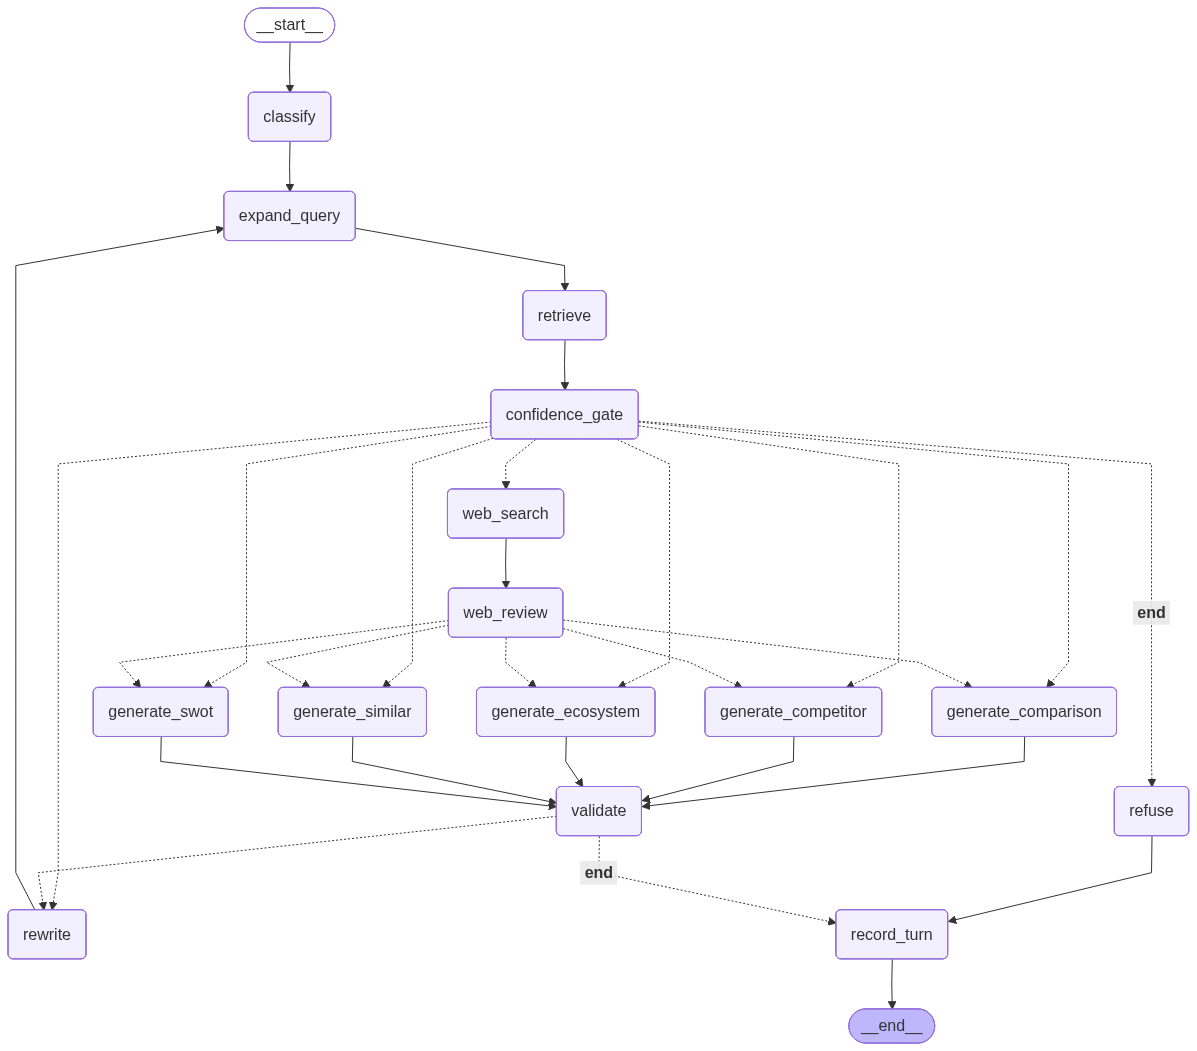

In [7]:
# ── 2b. Render as PNG in the notebook ───────────────────────────────────
from IPython.display import Image, display

png_bytes = graph.get_graph().draw_mermaid_png()
display(Image(png_bytes))

## 3. Basic Testing — Invoke the Graph

Run a few sample queries through the full pipeline and inspect results.

In [ ]:
# ── Test 1: Similar-company query ───────────────────────────────────────
result = graph.invoke({"user_query": "Find startups similar to Stripe in fintech"})

print(f"Analysis type : {result.get('analysis_type')}")
print(f"Confidence    : {result.get('confidence')}")
print(f"Best score    : {result.get('best_score', 0):.4f}")
print(f"Sources       : {len(result.get('source_docs', []))} docs")
print("─" * 60)
print(result.get("answer", "<no answer>"))

In [ ]:
# ── Test 2: SWOT query ──────────────────────────────────────────────────
result2 = graph.invoke({"user_query": "SWOT analysis of Airbnb"})

print(f"Analysis type : {result2.get('analysis_type')}")
print(f"Confidence    : {result2.get('confidence')}")
print(f"Best score    : {result2.get('best_score', 0):.4f}")
print(f"Sources       : {len(result2.get('source_docs', []))} docs")
print("─" * 60)
print(result2.get("answer", "<no answer>"))

In [ ]:
# ── Test 3: Edge case — nonsensical query (should trigger low/no confidence) ──
result3 = graph.invoke({"user_query": "xyzzy plugh nothing here 12345"})

print(f"Analysis type : {result3.get('analysis_type')}")
print(f"Confidence    : {result3.get('confidence')}")
print(f"Best score    : {result3.get('best_score', 0):.4f}")
print("─" * 60)
print(result3.get("answer", "<no answer>")[:300])

In [ ]:
# ── Test 4: Competitor query ────────────────────────────────────────────
result4 = graph.invoke({"user_query": "Who are the main competitors of Notion?"})

print(f"Analysis type : {result4.get('analysis_type')}")
print(f"Confidence    : {result4.get('confidence')}")
print(f"Best score    : {result4.get('best_score', 0):.4f}")
print(f"Sources       : {len(result4.get('source_docs', []))} docs")
print("─" * 60)
print(result4.get("answer", "<no answer>"))

## 4. Conversation Memory — Multi-Turn Test

Build a graph **with a checkpointer** and test follow-up queries that rely on conversation history.

Flow:
1. Ask about Stripe → get similar startups
2. Follow up with "Now do a SWOT for them" → model should resolve "them" = Stripe
3. Follow up with "What about their competitors?" → should still reference Stripe

In [ ]:
# ── 4a. Build graph WITH checkpointer ───────────────────────────────────
from langgraph.checkpoint.memory import MemorySaver

checkpointer = MemorySaver()  # in-memory for notebook (SqliteSaver in Streamlit)
memory_graph = build_graph(
    retriever=retriever, llm_client=llm_client, checkpointer=checkpointer,
)

# All turns share the same thread_id
THREAD_CONFIG = {"configurable": {"thread_id": "notebook-test-001"}}

print("Memory-enabled graph compiled!")
print(f"Thread ID: {THREAD_CONFIG['configurable']['thread_id']}")

In [ ]:
# ── 4b. Turn 1: Initial query about Stripe ──────────────────────────────
turn1 = memory_graph.invoke(
    {"user_query": "Find startups similar to Stripe"},
    config=THREAD_CONFIG,
)

print(f"Turn 1 — Analysis: {turn1.get('analysis_type')}")
print(f"         Confidence: {turn1.get('confidence')}")
print(f"         Sources: {len(turn1.get('source_docs', []))} docs")
print("─" * 60)
print(turn1.get("answer", "<no answer>")[:500])

In [ ]:
# ── 4c. Turn 2: Follow-up — "Now SWOT for them" ────────────────────────
# "them" should resolve to Stripe from conversation history
turn2 = memory_graph.invoke(
    {"user_query": "Now do a SWOT analysis for them"},
    config=THREAD_CONFIG,
)

print(f"Turn 2 — Analysis: {turn2.get('analysis_type')}  (expected: swot)")
print(f"         Confidence: {turn2.get('confidence')}")
print("─" * 60)
print(turn2.get("answer", "<no answer>")[:500])

In [ ]:
# ── 4d. Turn 3: Follow-up — "What about their competitors?" ─────────────
# "their" should still resolve to Stripe from accumulated history
turn3 = memory_graph.invoke(
    {"user_query": "What about their competitors?"},
    config=THREAD_CONFIG,
)

print(f"Turn 3 — Analysis: {turn3.get('analysis_type')}  (expected: competitor)")
print(f"         Confidence: {turn3.get('confidence')}")
print("─" * 60)
print(turn3.get("answer", "<no answer>")[:500])

In [ ]:
# ── 4e. Inspect accumulated conversation history ────────────────────────
# The checkpointer stores the full state — let's peek at the history
state_snapshot = memory_graph.get_state(THREAD_CONFIG)
history = state_snapshot.values.get("conversation_history", [])

print(f"Total turns in history: {len(history)}")
print("─" * 60)
for i, turn in enumerate(history):
    role = turn.get("role", "?")
    content = turn.get("content", "")[:120]
    print(f"  [{i}] {role}: {content}{'…' if len(turn.get('content', '')) > 120 else ''}")